In [139]:
# ライブラリ

In [2]:
import os
import glob
from IPython.display import display
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
#import japanize_matplotlib
import seaborn as sns 
import sweetviz as sv
import yaml

/Users/ishizuka/opt/anaconda3/envs/mufgcup2024/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# configの読み込み
CONFIG_FILE = '/Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [4]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]

In [5]:
pd.set_option("display.max_columns",100)
pd.set_option("display.max_rows", 500)

# データ読み込み

In [144]:
df_station = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATION))
df_status = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATUS))
df_trip = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_TRIP))
df_weather = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_WEATHER))

In [145]:
print(df_station.shape)
print(df_status.shape)
print(df_trip.shape)
print(df_weather.shape)

(70, 6)
(1226400, 8)
(669959, 8)
(730, 22)


In [146]:
df_station.head()

,station_id,lat,long,dock_count,city,installation_date
0,0,37.32973,-121.90178,27,city1,8/6/2013
1,1,37.33070,-121.88898,15,city1,8/5/2013
2,2,37.33399,-121.89490,11,city1,8/6/2013
3,3,37.33141,-121.89320,19,city1,8/5/2013
4,4,37.33672,-121.89407,15,city1,8/7/2013


In [147]:
df_status.head()

,id,year,month,day,hour,station_id,bikes_available,predict
0,0,2013,9,1,0,0,11.0,0
1,1,2013,9,1,1,0,11.0,0
2,2,2013,9,1,2,0,11.0,0
3,3,2013,9,1,3,0,11.0,0
4,4,2013,9,1,4,0,11.0,0


In [148]:
df_trip.head()

,trip_id,duration,start_date,start_station_id,end_date,end_station_id,bike_id,subscription_type
0,0,63,8/29/2013 14:13,54,8/29/2013 14:14,54,0,Subscriber
1,1,70,8/29/2013 14:42,8,8/29/2013 14:43,8,1,Subscriber
2,2,71,8/29/2013 10:16,20,8/29/2013 10:17,20,2,Subscriber
3,3,77,8/29/2013 11:29,8,8/29/2013 11:30,8,3,Subscriber
4,4,83,8/29/2013 12:02,54,8/29/2013 12:04,55,4,Subscriber


In [149]:
df_weather.head()

,date,max_temperature,mean_temperature,min_temperature,max_dew_point,mean_dew_point,min_dew_point,max_humidity,mean_humidity,min_humidity,max_sea_level_pressure,mean_sea_level_pressure,min_sea_level_pressure,max_visibility,mean_visibility,min_visibility,max_wind_Speed,mean_wind_speed,precipitation,cloud_cover,events,wind_dir_degrees
0,2013-09-01,81,70,61,62,58,54,80,67,47,29.94,29.95,29.85,10,10,10,14,4,0.00,1,NaN,354
1,2013-09-02,80,71,66,64,61,58,80,70,58,29.95,29.95,29.86,10,10,10,14,4,0.00,5,NaN,337
2,2013-09-03,81,69,58,60,56,52,82,65,44,29.99,29.99,29.93,10,10,10,19,2,1.71,6,Rain,341
3,2013-09-04,82,68,56,61,55,49,81,64,43,30.04,30.02,29.94,10,10,10,15,0,0.00,0,NaN,324
4,2013-09-05,81,68,56,59,54,50,81,63,41,30.02,30.02,29.95,10,10,10,16,1,0.00,0,NaN,335


In [150]:
(70 - 32) * 5.0/9.0

21.11111111111111

# 型、項目数、欠損値率

In [151]:
def calc_describe(df):
    dtypes = []
    val_counts_station = []
    isnull_station = []
    isnull_station_ratio = 100 * df.isnull().sum() / len(df)
    for col in df.columns:
        dtypes.append(str(df[col].dtype))
        val_counts_station.append(len(df[col].value_counts()))
        isnull_station.append(isnull_station_ratio[col])
    inds = ["型", "val_counts", "NaN率"]
    df_eda = pd.DataFrame([dtypes, val_counts_station, isnull_station], columns=df.columns, index=inds).T
    # df_eda.query("val_counts > 1")
    return df_eda

In [152]:
df_eda_station = calc_describe(df_station)
df_eda_station

,型,val_counts,NaN率
station_id,int64,70,0.0
lat,float64,69,0.0
long,float64,70,0.0
dock_count,int64,6,0.0
city,object,5,0.0
installation_date,object,17,0.0


In [153]:
df_eda_status = calc_describe(df_status)
df_eda_status

,型,val_counts,NaN率
id,int64,1226400,0.0
year,int64,3,0.0
month,int64,12,0.0
day,int64,31,0.0
hour,int64,24,0.0
station_id,int64,70,0.0
bikes_available,float64,28,17.818167
predict,int64,2,0.0


In [154]:
df_eda_trip = calc_describe(df_trip)
df_eda_trip

,型,val_counts,NaN率
trip_id,int64,669959,0.0
duration,int64,16129,0.0
start_date,object,361559,0.0
start_station_id,int64,70,0.0
end_date,object,357757,0.0
end_station_id,int64,70,0.0
bike_id,int64,700,0.0
subscription_type,object,2,0.0


In [155]:
df_eda_weather = calc_describe(df_weather)
df_eda_weather

,型,val_counts,NaN率
date,object,730,0.0
max_temperature,int64,48,0.0
mean_temperature,int64,41,0.0
min_temperature,int64,37,0.0
max_dew_point,int64,39,0.0
mean_dew_point,int64,39,0.0
min_dew_point,int64,47,0.0
max_humidity,int64,43,0.0
mean_humidity,int64,55,0.0
min_humidity,int64,65,0.0


# 基本統計量

In [156]:
df_station.describe()

,station_id,lat,long,dock_count
count,70.000000,70.000000,70.000000,70.000000
mean,34.500000,37.590244,-122.218416,17.657143
std,20.351085,0.203473,0.209446,4.010442
min,0.000000,37.329730,-122.418950,11.000000
25%,17.250000,37.389485,-122.400600,15.000000
50%,34.500000,37.631165,-122.312120,15.000000
75%,51.750000,37.788125,-122.078008,19.000000
max,69.000000,37.804770,-121.877350,27.000000


In [157]:
df_status.describe()

,id,year,month,day,hour,station_id,bikes_available,predict
count,1.226400e+06,1.226400e+06,1.226400e+06,1.226400e+06,1.226400e+06,1.226400e+06,1.007878e+06,1.226400e+06
mean,6.131995e+05,2.014166e+03,6.526027e+00,1.572055e+01,1.150000e+01,3.450000e+01,8.428755e+00,1.575342e-01
std,3.540313e+05,6.874054e-01,3.447853e+00,8.796251e+00,6.922189e+00,2.020521e+01,3.953576e+00,3.643039e-01
min,0.000000e+00,2.013000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.065998e+05,2.014000e+03,4.000000e+00,8.000000e+00,5.750000e+00,1.700000e+01,6.000000e+00,0.000000e+00
50%,6.131995e+05,2.014000e+03,7.000000e+00,1.600000e+01,1.150000e+01,3.450000e+01,8.000000e+00,0.000000e+00
75%,9.197992e+05,2.015000e+03,1.000000e+01,2.300000e+01,1.725000e+01,5.200000e+01,1.100000e+01,0.000000e+00
max,1.226399e+06,2.015000e+03,1.200000e+01,3.100000e+01,2.300000e+01,6.900000e+01,2.700000e+01,1.000000e+00


In [158]:
df_trip.describe()

,trip_id,duration,start_station_id,end_station_id,bike_id
count,669959.000000,6.699590e+05,669959.000000,669959.000000,669959.00000
mean,334979.000000,1.107950e+03,47.144845,47.177594,281.98319
std,193400.648836,2.225544e+04,14.669843,14.733621,186.50497
min,0.000000,6.000000e+01,0.000000,0.000000,0.00000
25%,167489.500000,3.440000e+02,40.000000,39.000000,127.00000
50%,334979.000000,5.170000e+02,50.000000,50.000000,254.00000
75%,502468.500000,7.550000e+02,58.000000,58.000000,421.00000
max,669958.000000,1.727040e+07,69.000000,69.000000,699.00000


In [159]:
df_weather.describe()

,max_temperature,mean_temperature,min_temperature,max_dew_point,mean_dew_point,min_dew_point,max_humidity,mean_humidity,min_humidity,max_sea_level_pressure,mean_sea_level_pressure,min_sea_level_pressure,max_visibility,mean_visibility,min_visibility,max_wind_Speed,mean_wind_speed,precipitation,cloud_cover,wind_dir_degrees
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,71.424658,61.357534,51.582192,53.204110,48.554795,43.812329,83.745205,65.858904,46.334247,30.081671,30.031274,29.967479,9.994521,9.654795,8.439726,16.742466,4.763014,0.030329,1.836986,270.158904
std,8.185802,7.683171,7.913071,6.993294,7.960319,9.411146,8.646749,9.439466,13.068903,0.132638,0.130428,0.131095,0.073871,0.892745,2.667142,7.314190,2.510882,0.187340,2.062002,118.615872
min,46.000000,38.000000,28.000000,23.000000,15.000000,8.000000,40.000000,28.000000,11.000000,29.500000,29.440000,29.360000,9.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,66.000000,56.000000,46.000000,49.000000,44.000000,37.000000,80.000000,61.000000,38.000000,29.982500,29.940000,29.880000,10.000000,10.000000,8.000000,14.000000,2.000000,0.000000,0.000000,262.500000
50%,71.000000,62.000000,52.000000,54.000000,49.000000,45.000000,84.000000,67.000000,47.000000,30.070000,30.020000,29.960000,10.000000,10.000000,10.000000,16.000000,5.000000,0.000000,1.000000,331.000000
75%,77.000000,68.000000,58.000000,59.000000,55.000000,51.000000,89.000000,72.000000,55.000000,30.170000,30.120000,30.060000,10.000000,10.000000,10.000000,20.000000,7.000000,0.000000,3.000000,345.000000
max,99.000000,82.000000,66.000000,66.000000,62.000000,60.000000,100.000000,92.000000,84.000000,30.480000,30.410000,30.350000,10.000000,10.000000,10.000000,114.000000,14.000000,3.360000,8.000000,360.000000


# 前処理済データの読み込み

In [6]:
df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_prep_trip = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_prep_weather = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

# station

In [161]:
import folium

In [162]:
# 地図オブジェクトを作成
m = folium.Map(location=[37.48176, -122.22690], zoom_start=9)

# データフレームの各行に対してマーカーを追加
def get_color(city):
    if city == "city1":
        return "blue"
    elif city == "city2":
        return "purple"
    elif city == "city3":
        return "orange"
    elif city == "city4":
        return "green"
    elif city == "city5":
        return "red"
    else:
        raise ValueError("city not found")
    

for index, row in df_prep_station.iterrows():
    folium.Marker(
        location=[row['lat'], row['long']],
        popup=row['station_id'],
        icon=folium.Icon(icon='info-sign',color=get_color(row['city']))
    ).add_to(m)

m

<Axes: xlabel='station_id', ylabel='dock_count'>

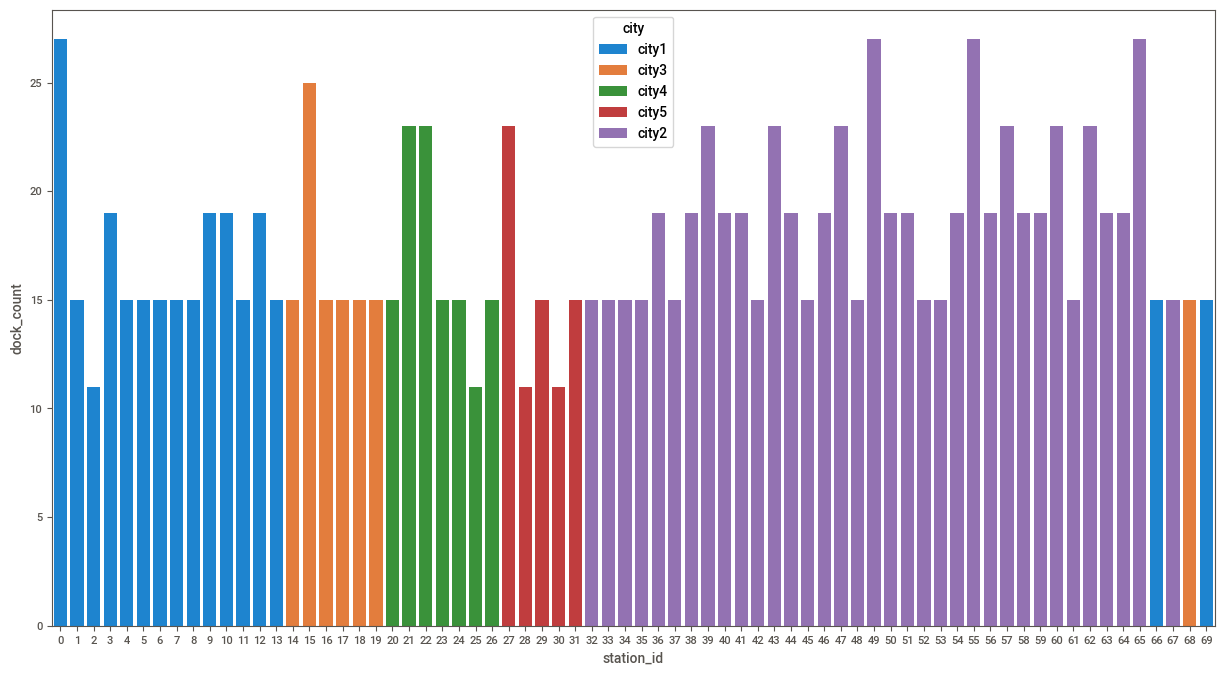

In [163]:
# station_idごとのdock_countをプロット
# cityごとに色分け
plt.figure(figsize=(15, 8))
sns.barplot(data=df_prep_station, x="station_id", y="dock_count", hue="city")

In [164]:
df_prep_station.groupby("city").mean()["dock_count"]

city
city1    16.500000
city2    19.000000
city3    16.428571
city4    16.714286
city5    15.000000
Name: dock_count, dtype: float64

<Axes: xlabel='installation_date', ylabel='dock_count'>

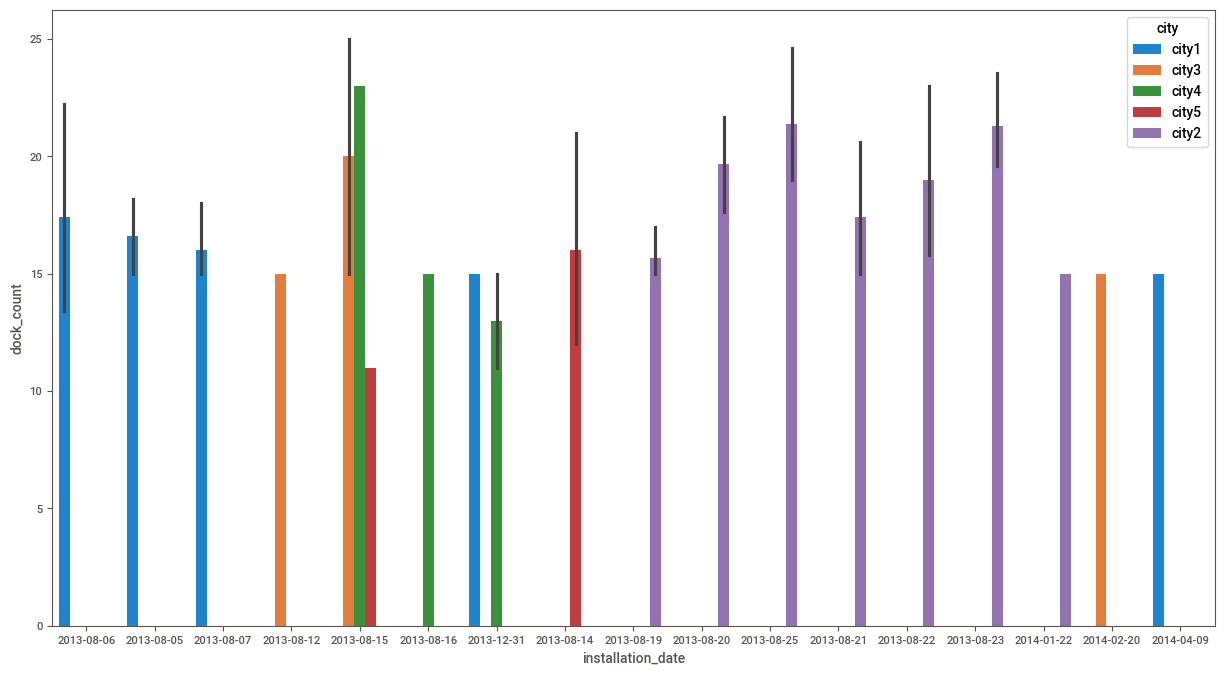

In [351]:
# install_dateの年ごとのdock_countをcity別にプロット
plt.figure(figsize=(15, 8))
sns.barplot(data=df_prep_station, x="installation_date", y="dock_count", hue="city")

# status

In [7]:
df_prep_status.head()

,id,year,month,day,hour,station_id,bikes_available,predict,datetime
0,0,2013,9,1,0,0,11.0,0,2013-09-01 00:00:00
1,1,2013,9,1,1,0,11.0,0,2013-09-01 01:00:00
2,2,2013,9,1,2,0,11.0,0,2013-09-01 02:00:00
3,3,2013,9,1,3,0,11.0,0,2013-09-01 03:00:00
4,4,2013,9,1,4,0,11.0,0,2013-09-01 04:00:00


In [8]:
df_prep_status_station = pd.merge(df_prep_status, df_prep_station, on="station_id", how="left")

In [9]:
df_prep_status_station.head()


,id,year,month,day,hour,station_id,bikes_available,predict,datetime,lat,long,dock_count,city,installation_date
0,0,2013,9,1,0,0,11.0,0,2013-09-01 00:00:00,37.32973,-121.90178,27,city1,2013-08-06
1,1,2013,9,1,1,0,11.0,0,2013-09-01 01:00:00,37.32973,-121.90178,27,city1,2013-08-06
2,2,2013,9,1,2,0,11.0,0,2013-09-01 02:00:00,37.32973,-121.90178,27,city1,2013-08-06
3,3,2013,9,1,3,0,11.0,0,2013-09-01 03:00:00,37.32973,-121.90178,27,city1,2013-08-06
4,4,2013,9,1,4,0,11.0,0,2013-09-01 04:00:00,37.32973,-121.90178,27,city1,2013-08-06


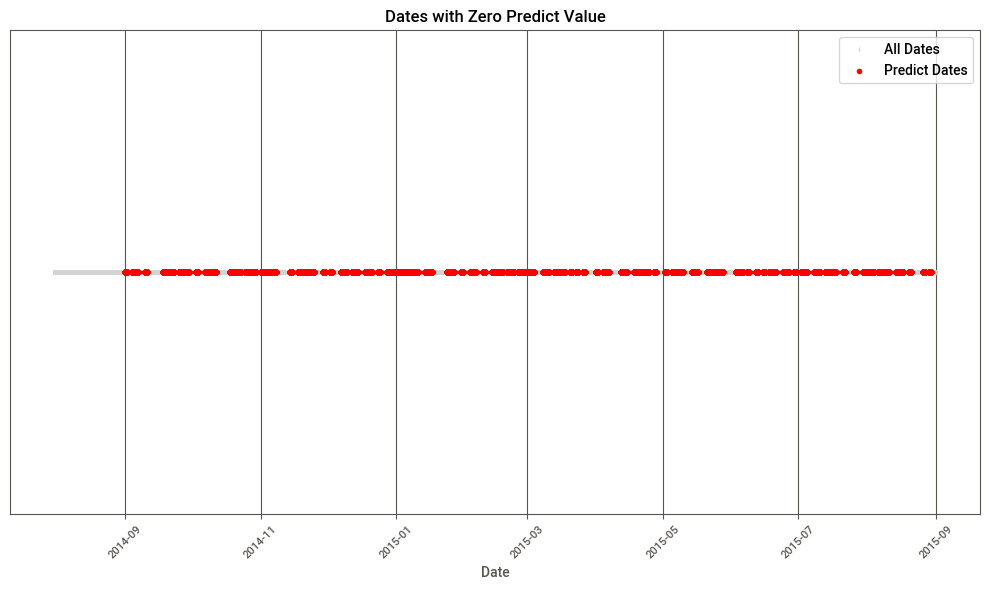

In [263]:
df_ = df_prep_status_station[df_prep_status_station["datetime"] > "2014-07-31"]
df_test_prep_status_station = df_[df_["predict"] == 1]

# 時系列のうち、強調したい日付（predictが0のもの）だけを強調して可視化
plt.figure(figsize=(10, 6))
plt.plot(df_['datetime'], [1] * len(df_), color='lightgray', label='All Dates', marker='|', linestyle='')

# predictが0の日付を強調
plt.scatter(df_test_prep_status_station['datetime'], [1]*len(df_test_prep_status_station), color='red', label='Predict Dates', zorder=4)

# グラフの設定
plt.title('Dates with Zero Predict Value')
plt.xlabel('Date')
plt.yticks([])  # 縦軸のラベルを消去
plt.legend()
plt.grid(True, axis='x')
plt.xticks(rotation=45)

# グラフを表示
plt.tight_layout()
plt.show()

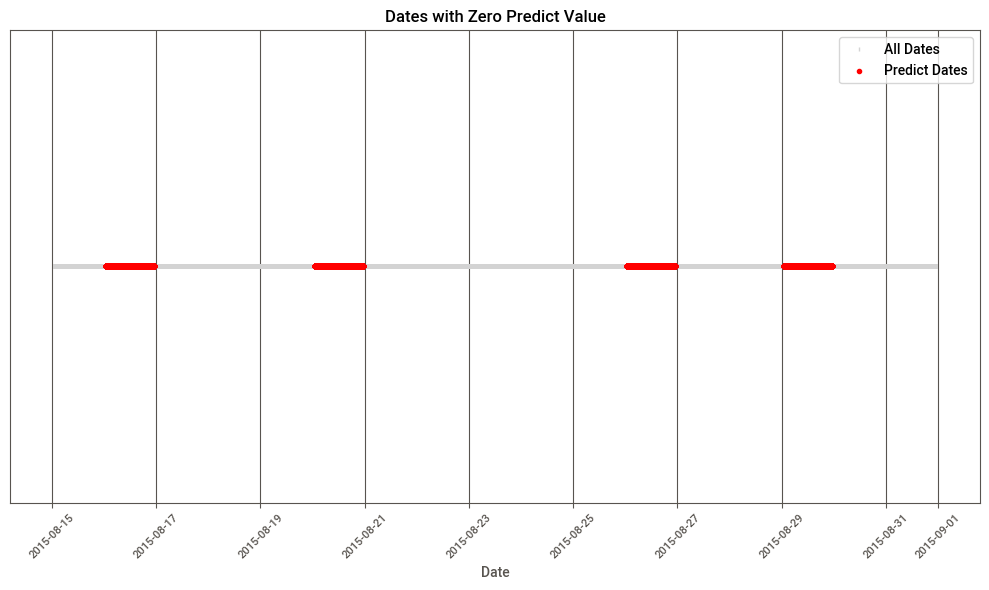

In [264]:
df_ = df_prep_status_station[df_prep_status_station["datetime"] > "2015-08-15"]
df_test_prep_status_station = df_[df_["predict"] == 1]

# 時系列のうち、強調したい日付（predictが0のもの）だけを強調して可視化
plt.figure(figsize=(10, 6))
plt.plot(df_['datetime'], [1] * len(df_), color='lightgray', label='All Dates', marker='|', linestyle='')

# predictが0の日付を強調
plt.scatter(df_test_prep_status_station['datetime'], [1]*len(df_test_prep_status_station), color='red', label='Predict Dates', zorder=5)

# グラフの設定
plt.title('Dates with Zero Predict Value')
plt.xlabel('Date')
plt.yticks([])  # 縦軸のラベルを消去
plt.legend()
plt.grid(True, axis='x')
plt.xticks(rotation=45)

# グラフを表示
plt.tight_layout()
plt.show()

In [258]:
# predict==1の割合を年月別に計算
df_prep_status_station["year_month"] = df_prep_status_station["datetime"].dt.strftime("%Y-%m")
df_prep_status_station["predict"] = df_prep_status_station["predict"].astype(int)
df_predict_ratio = df_prep_status_station.groupby("year_month")["predict"].mean()
df_predict_ratio

year_month
2013-09    0.000000
2013-10    0.000000
2013-11    0.000000
2013-12    0.000000
2014-01    0.000000
2014-02    0.000000
2014-03    0.000000
2014-04    0.000000
2014-05    0.000000
2014-06    0.000000
2014-07    0.000000
2014-08    0.000000
2014-09    0.319444
2014-10    0.309140
2014-11    0.319444
2014-12    0.309140
2015-01    0.309140
2015-02    0.342262
2015-03    0.309140
2015-04    0.319444
2015-05    0.309140
2015-06    0.319444
2015-07    0.309140
2015-08    0.309140
Name: predict, dtype: float64

In [55]:
# predict==1同士の間隔を計算
df_ = df_prep_status_station[df_prep_status_station["predict"] == 1]
df_["date"] = df_["datetime"].dt.date
df_ = df_.groupby("date").count().reset_index()
df_["diff"] = df_["date"].diff().dt.days
df_["diff"].value_counts().sort_index()

/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_37763/1237091911.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_["date"] = df_["datetime"].dt.date


diff
2.0    60
3.0    24
4.0    20
5.0     7
6.0     3
7.0     3
8.0     2
Name: count, dtype: int64

In [66]:
df_prep_status_station

,id,year,month,day,hour,station_id,bikes_available,predict,datetime,lat,long,dock_count,city,installation_date
0,0,2013,9,1,0,0,11.0,0,2013-09-01 00:00:00,37.32973,-121.90178,27,city1,2013-08-06
1,1,2013,9,1,1,0,11.0,0,2013-09-01 01:00:00,37.32973,-121.90178,27,city1,2013-08-06
2,2,2013,9,1,2,0,11.0,0,2013-09-01 02:00:00,37.32973,-121.90178,27,city1,2013-08-06
3,3,2013,9,1,3,0,11.0,0,2013-09-01 03:00:00,37.32973,-121.90178,27,city1,2013-08-06
4,4,2013,9,1,4,0,11.0,0,2013-09-01 04:00:00,37.32973,-121.90178,27,city1,2013-08-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1226395,1226395,2015,8,31,19,69,8.0,0,2015-08-31 19:00:00,37.34273,-121.89562,15,city1,2014-04-09
1226396,1226396,2015,8,31,20,69,8.0,0,2015-08-31 20:00:00,37.34273,-121.89562,15,city1,2014-04-09
1226397,1226397,2015,8,31,21,69,8.0,0,2015-08-31 21:00:00,37.34273,-121.89562,15,city1,2014-04-09
1226398,1226398,2015,8,31,22,69,8.0,0,2015-08-31 22:00:00,37.34273,-121.89562,15,city1,2014-04-09


In [124]:
def create_valid_flag(df_result):
    df_ = df_result.copy()
    df_ = df_[df_["predict"] != 0]
    df_["date"] = df_["datetime"].dt.date
    df_ = df_[["date","predict"]].drop_duplicates()
    df_["diff"] = df_["date"].diff().dt.days
    df_["yesterday"] = df_["date"].apply(lambda x: x - pd.Timedelta(days=1))
    list_valid_date = df_[df_["diff"] >= 4.0]["yesterday"].tolist()
    df_result_ = df_result.copy()
    # dateがlist_valid_dateに含まれている場合はpredictを2にする
    df_result_["predict"] = df_result_.apply(lambda x: 2 if (x["datetime"].date() in list_valid_date) & (x["datetime"].hour!=0) else x["predict"], axis=1)
    return df_result_

In [125]:
past_2_len = 0
df_result = df_prep_status_station.copy()
while True:
    df_result = create_valid_flag(df_result)
    current_2_len = len(df_result[df_result["predict"] == 2])
    if current_2_len == past_2_len:
        break
    past_2_len = current_2_len

In [145]:
df_result["predict"].value_counts()

predict
0    928550
1    193200
2    104650
Name: count, dtype: int64

In [146]:
df_ = df_result[df_result["predict"]==2]
df_["date"] = df_["datetime"].dt.date
df_ = df_[["date"]].drop_duplicates()
print(len(df_))
print(len(df_)/365)

65
0.1780821917808219


/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_37763/4159198662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_["date"] = df_["datetime"].dt.date


In [147]:
df_["date"].apply(lambda x: f"{x.year}-{x.month}").value_counts().sort_index()

date
2014-10    6
2014-11    7
2014-12    5
2014-9     6
2015-1     7
2015-2     3
2015-3     5
2015-4     5
2015-5     7
2015-6     4
2015-7     5
2015-8     5
Name: count, dtype: int64

In [148]:
df_["date"].apply(lambda x: x.weekday()).value_counts().sort_index()

date
0    10
1    14
2     9
3    11
4     9
5     7
6     5
Name: count, dtype: int64

In [149]:
df_ = df_result.copy()
df_ = df_[df_["predict"] != 0]
df_["date"] = df_["datetime"].dt.date
df_ = df_[["date","predict"]].drop_duplicates()
df_["diff"] = df_["date"].diff().dt.days
df_["diff"].value_counts().sort_index() 

diff
1.0    65
2.0    60
3.0    59
Name: count, dtype: int64

In [ ]:
# 学習対象の欠損値
df_prep_status_station[(df_prep_status_station["predict"]==0) & (df_prep_status_station["bikes_available"].isnull())].shape

(25322, 15)

In [ ]:
# 基本的なEDA（sweetbiz）
my_report = sv.compare([df_prep_status_station[df_prep_status_station["predict"]==0].dropna(subset=["bikes_available"]), "train"],
                       [df_prep_status_station[df_prep_status_station["predict"]==1].drop(columns=["bikes_available"]), "test"],
                        "bikes_available")

my_report.show_html(os.path.join(DIR_FIGURE, "sweetviz_report_2col.html"))

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/data/figures/sweetviz_report_2col.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


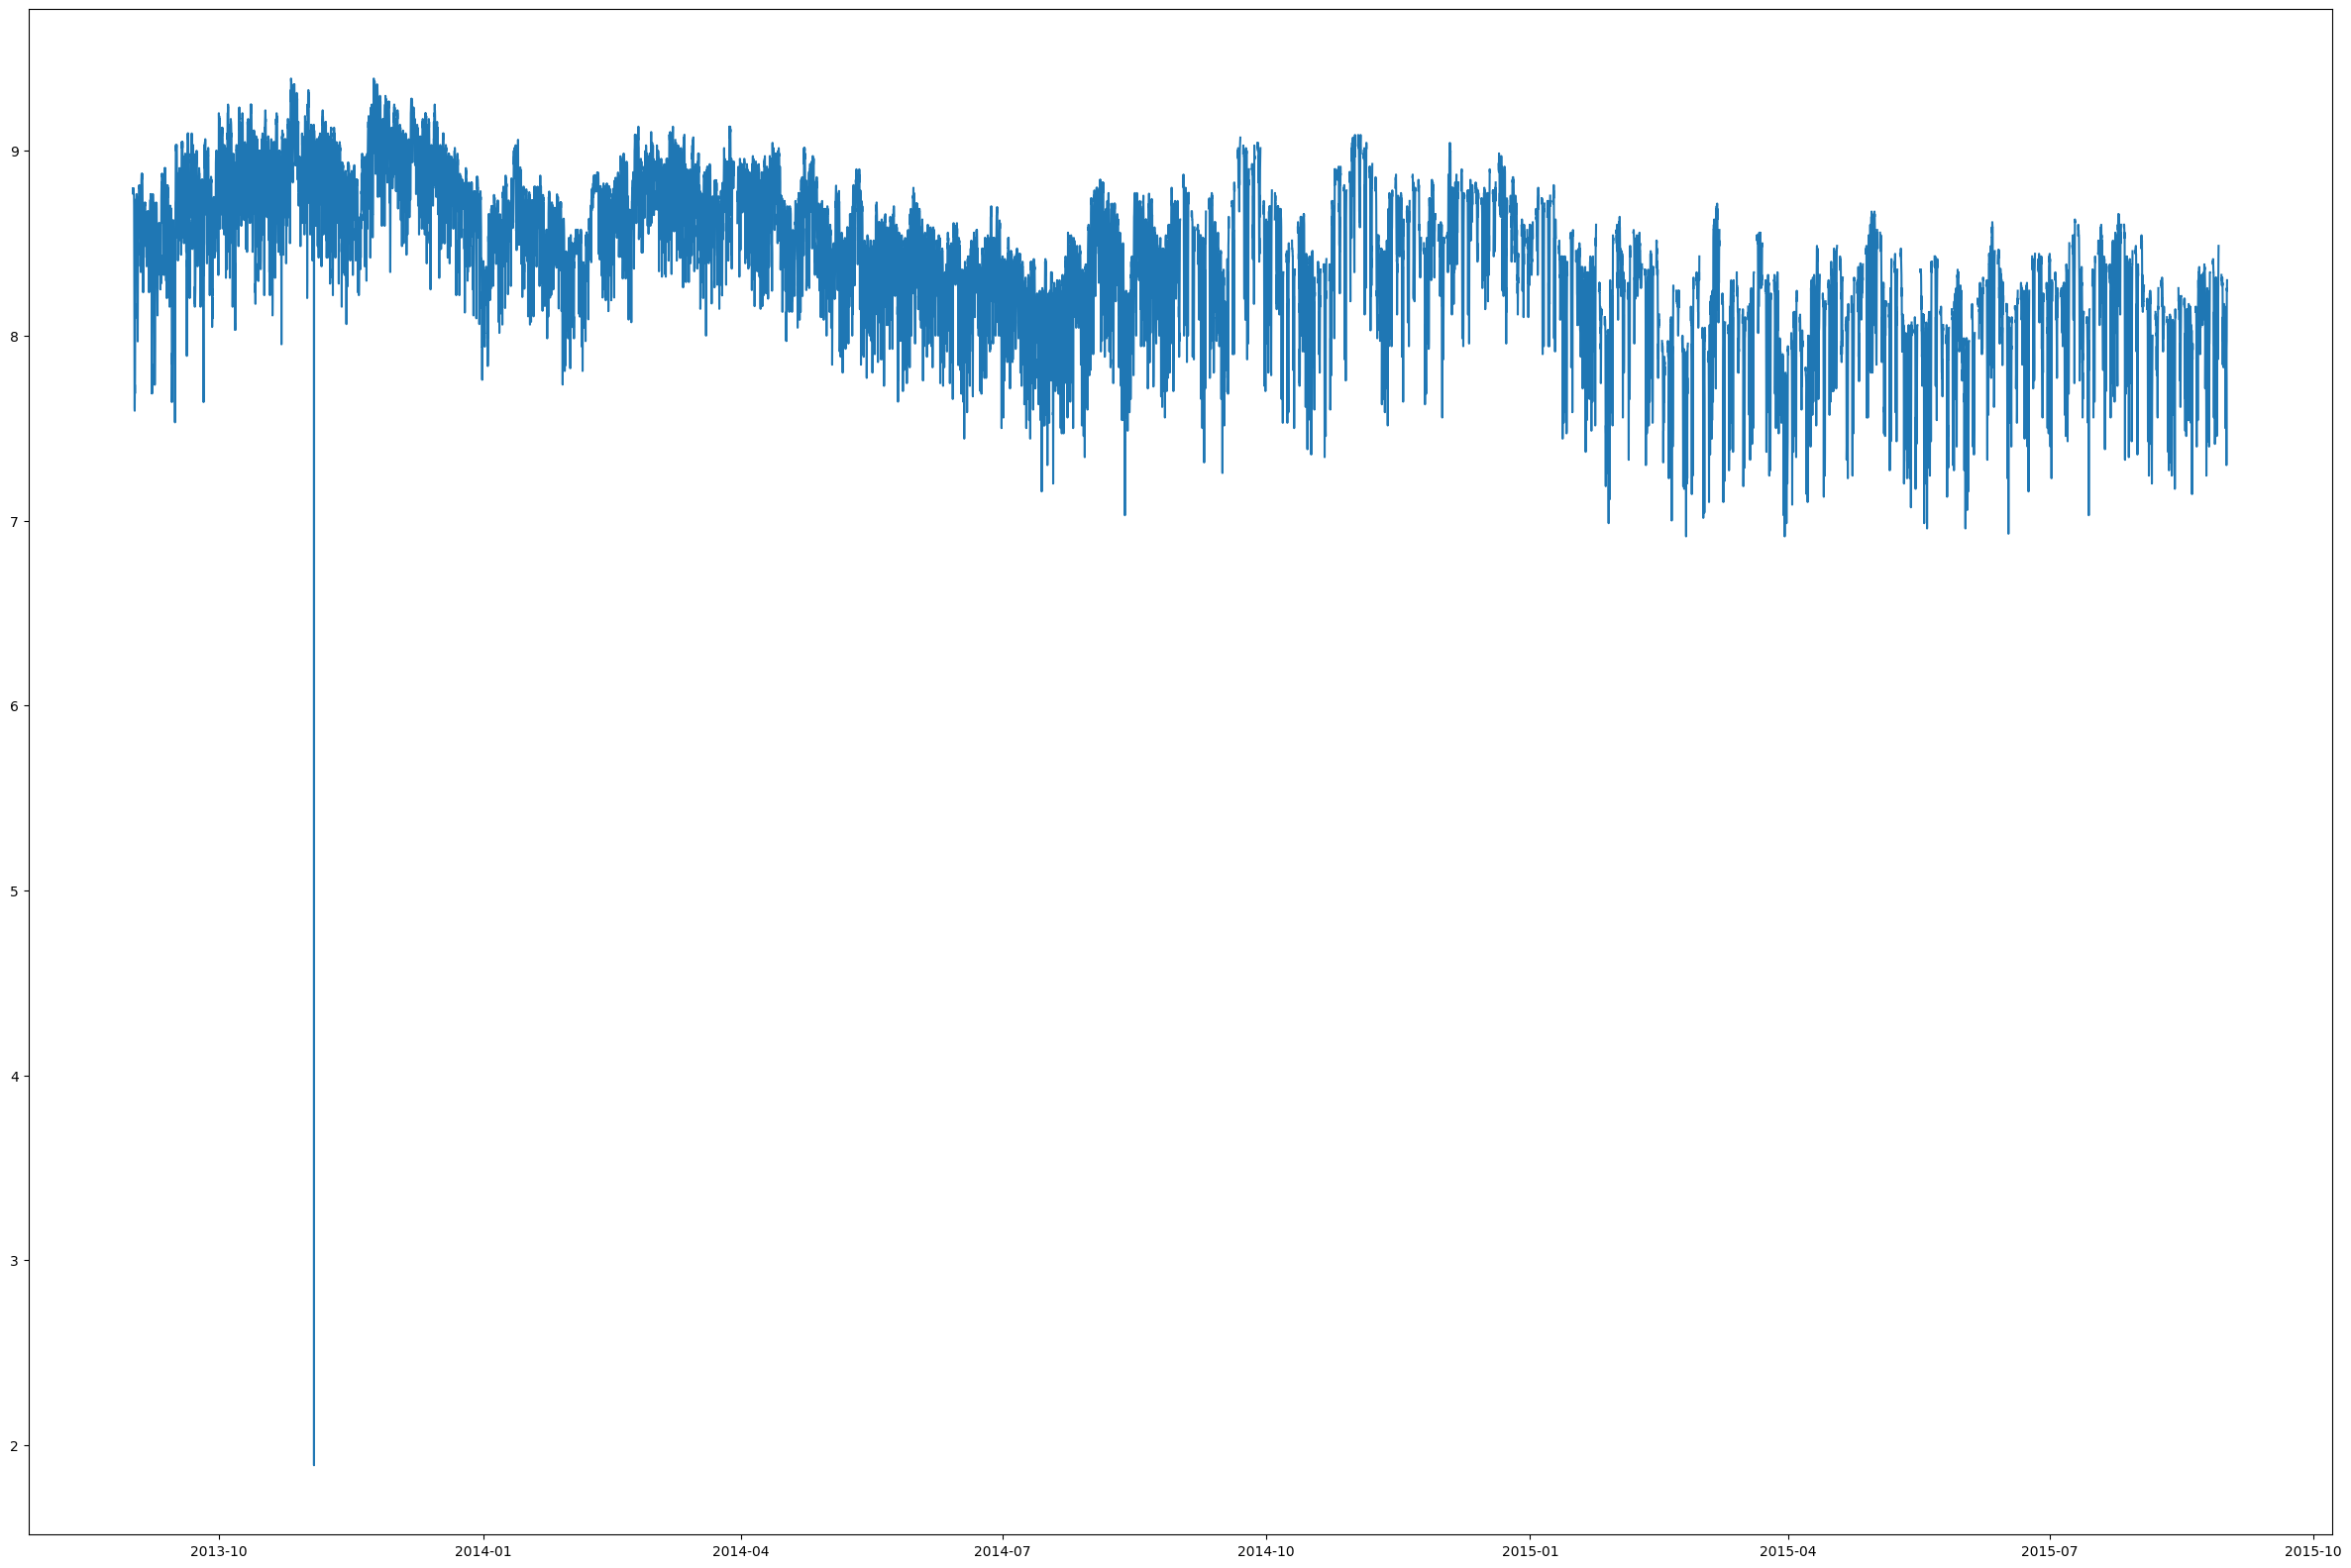

In [ ]:
# bikes_availableの平均値プロット
plt.figure(figsize=(30, 20))
df_ = df_prep_status_station.groupby("datetime")["bikes_available"].mean().reset_index()
plt.plot(df_["datetime"], df_["bikes_available"])

In [197]:
# 外れ値
df_ = df_prep_status_station.groupby("datetime")["bikes_available"].mean().reset_index()
df_[df_["bikes_available"]<3]

,datetime,bikes_available
1514,2013-11-03 02:00:00,1.890625


In [ ]:
df_prep_status_station[df_prep_status_station["datetime"] == "2013-11-03 02:00:00"]

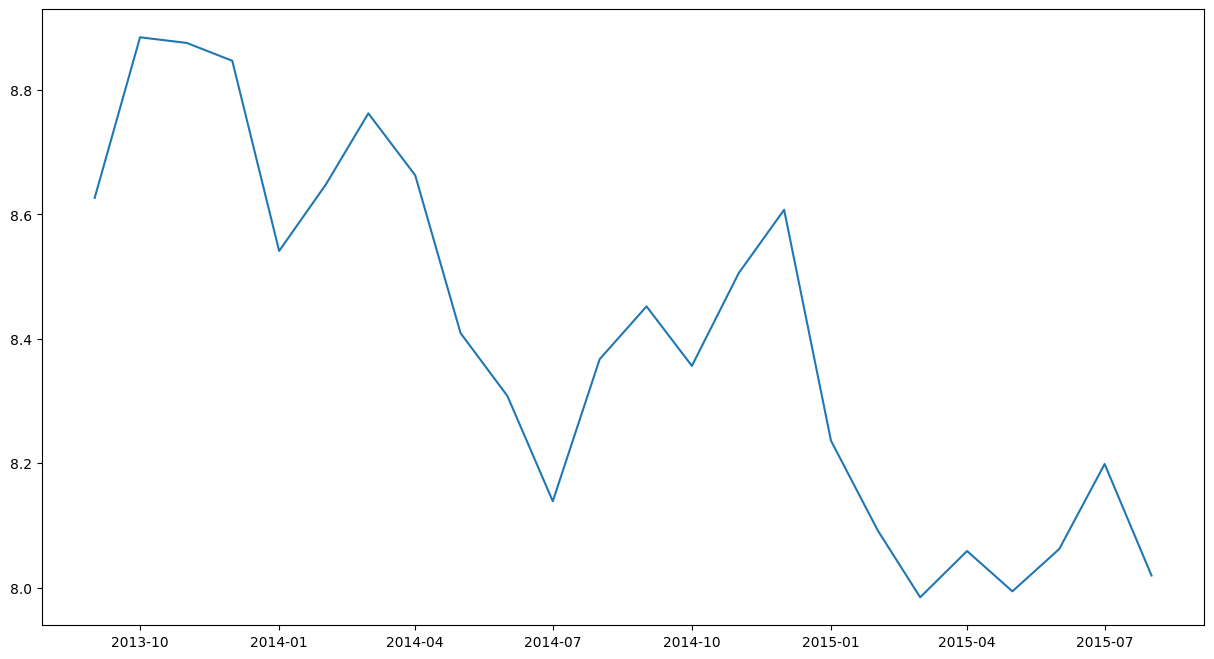

In [ ]:
# bikes_availableの平均値を月次でプロット
plt.figure(figsize=(15, 8))
df_prep_status_station["datetime_ym"] = df_prep_status_station["datetime"].dt.to_period("M")
df_ = df_prep_status_station.groupby("datetime_ym")["bikes_available"].mean().reset_index()
plt.plot(df_["datetime_ym"].apply(lambda x: x.to_timestamp()), df_["bikes_available"])

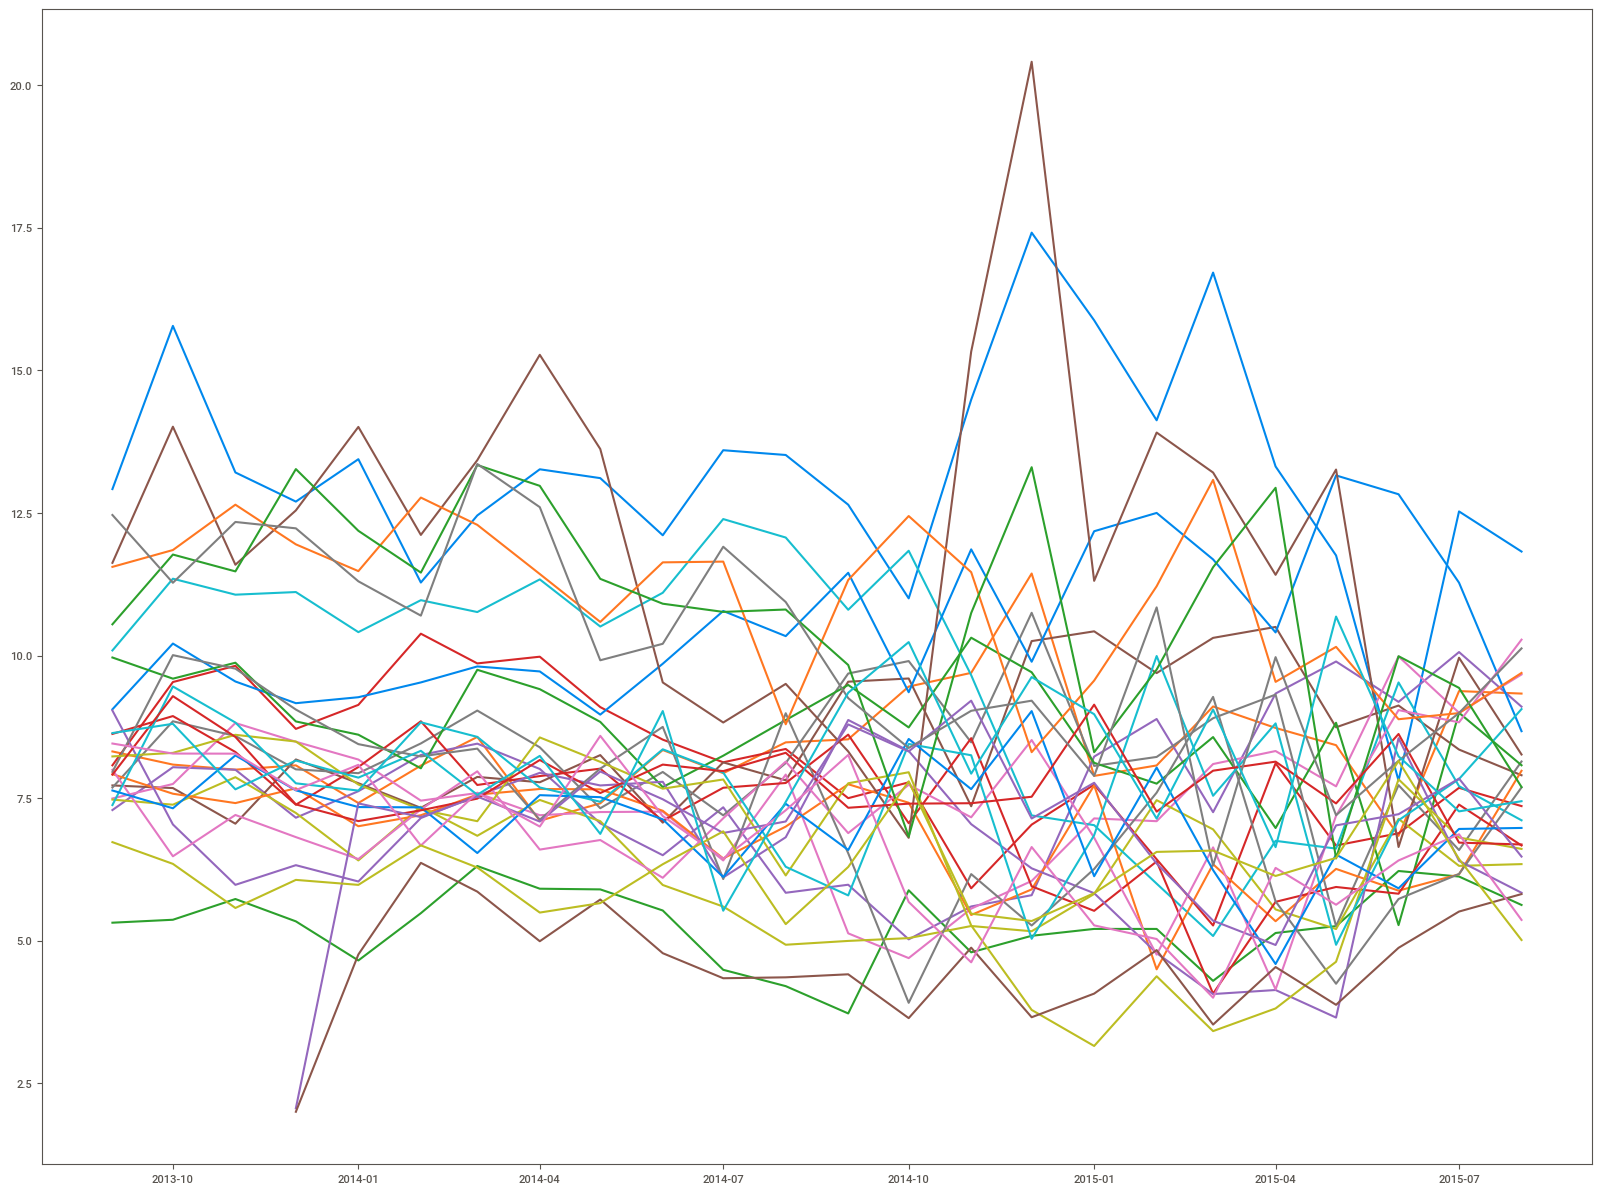

In [342]:
# 全てのstation_idについて、bikes_availableの平均値を日次でプロット
plt.figure(figsize=(20, 15))
df_ = df_prep_status_station.copy()
df_["datetime"] = df_["datetime"].dt.to_period("M")
df_ = df_.groupby(["datetime", "station_id"])["bikes_available"].mean().reset_index()
for station_id in range(30):
    df__ = df_[df_["station_id"] == station_id]
    plt.plot(df__["datetime"].apply(lambda x: x.to_timestamp()), df__["bikes_available"], label=station_id)

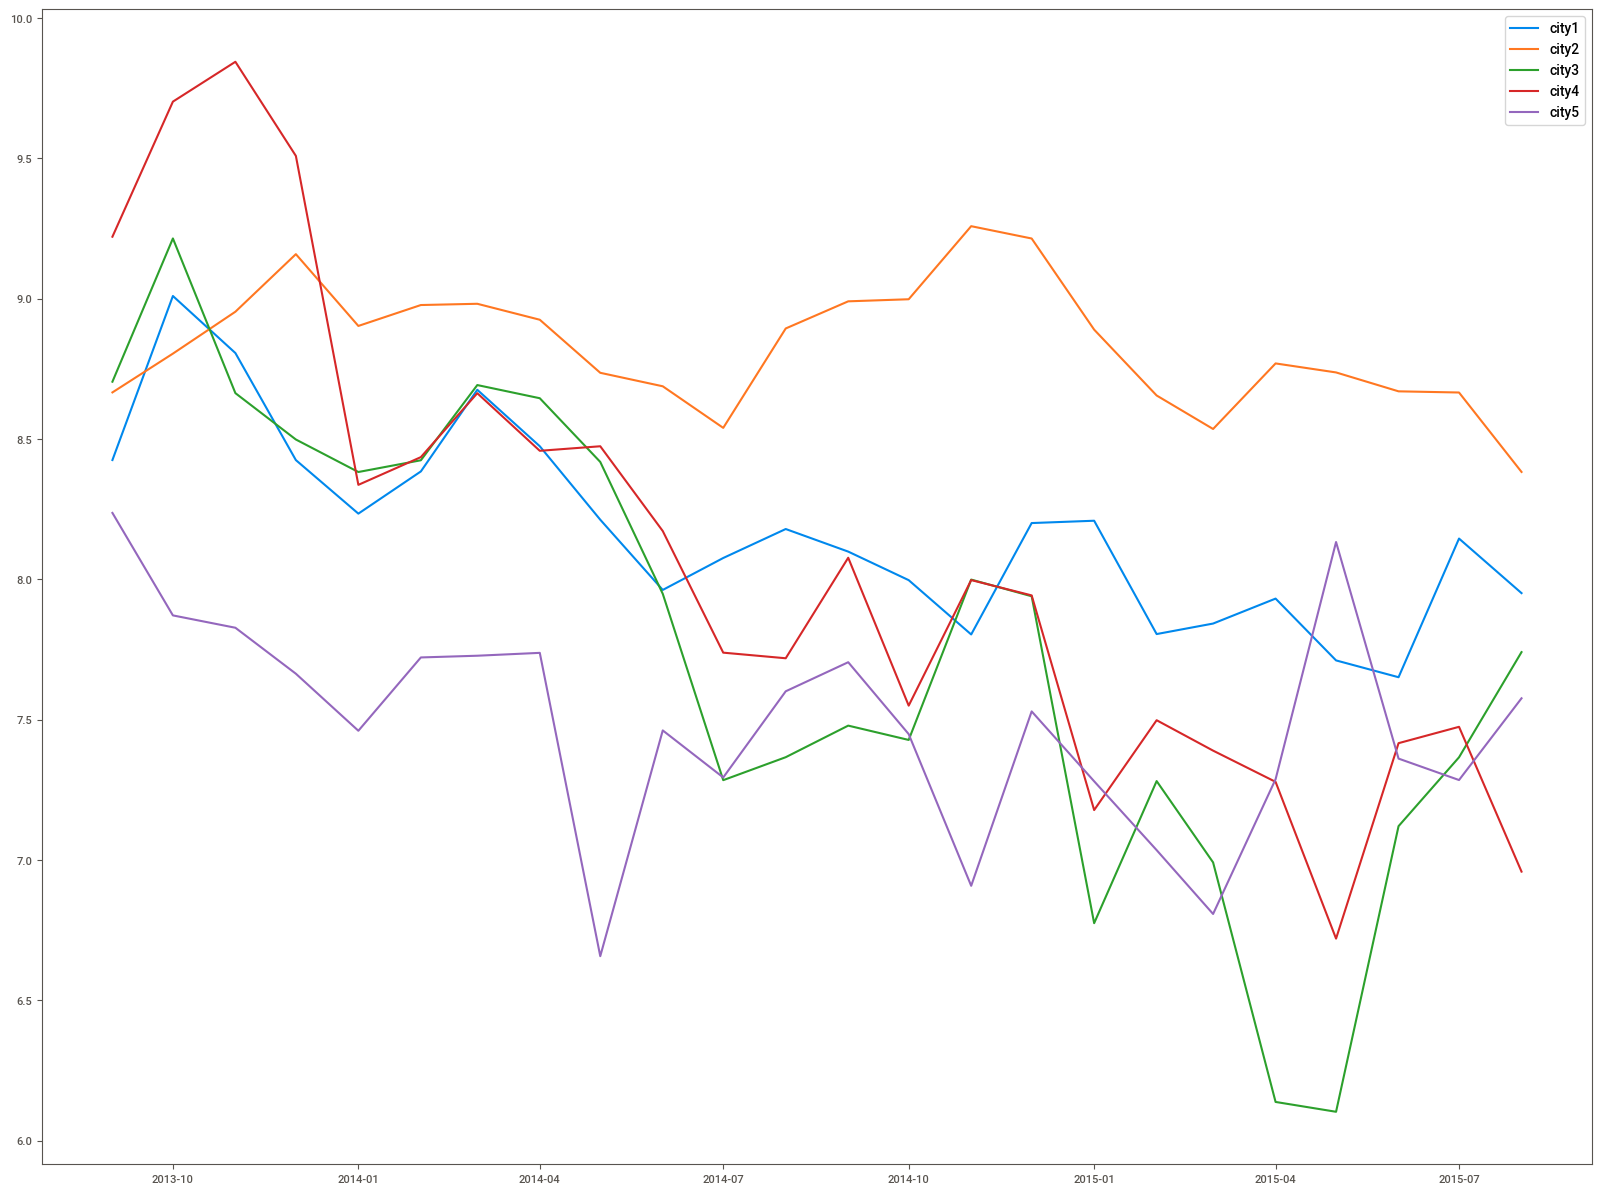

In [346]:
# cityごとのbikes_availableの平均値を月次でプロット
plt.figure(figsize=(20, 15))
df_ = df_prep_status_station.copy()
df_["datetime"] = df_["datetime"].dt.to_period("M")
df_ = df_.groupby(["datetime", "city"])["bikes_available"].mean().reset_index()
for city in df_["city"].unique():
    df__ = df_[df_["city"] == city]
    plt.plot(df__["datetime"].apply(lambda x: x.to_timestamp()), df__["bikes_available"], label=city)
plt.legend()

# trip

In [203]:
df_prep_trip.head()

,trip_id,duration,start_date,start_station_id,end_date,end_station_id,bike_id,subscription_type
0,0,63,2013-08-29 14:13:00,54,2013-08-29 14:14:00,54,0,Subscriber
1,1,70,2013-08-29 14:42:00,8,2013-08-29 14:43:00,8,1,Subscriber
2,2,71,2013-08-29 10:16:00,20,2013-08-29 10:17:00,20,2,Subscriber
3,3,77,2013-08-29 11:29:00,8,2013-08-29 11:30:00,8,3,Subscriber
4,4,83,2013-08-29 12:02:00,54,2013-08-29 12:04:00,55,4,Subscriber


<Axes: xlabel='start_date_ym'>

<Figure size 1500x800 with 0 Axes>

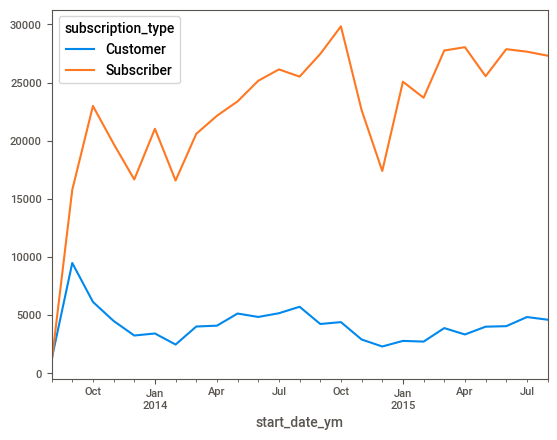

In [207]:
# subscription_typeごとのtrip_id数を時系列で月次プロット
plt.figure(figsize=(15, 8))
df_prep_trip["start_date_ym"] = df_prep_trip["start_date"].dt.to_period("M")
df_ = df_prep_trip.groupby(["start_date_ym", "subscription_type"]).size().unstack().fillna(0)
df_.plot()

<Axes: xlabel='start_date_ymd'>

<Figure size 2000x800 with 0 Axes>

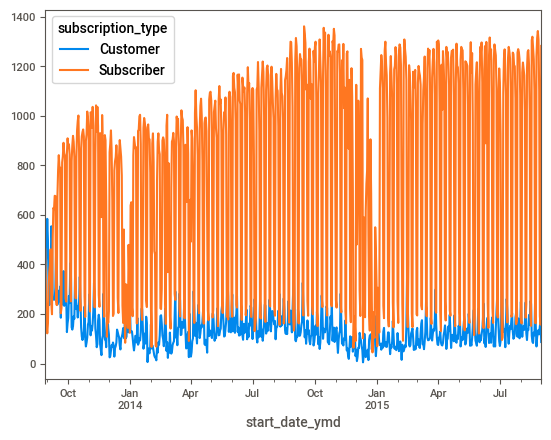

In [265]:
# subscription_typeごとのtrip_id数を時系列で日次プロット
df_ = df_prep_trip#[df_prep_trip["start_date"]>"2015-08-01"]
df_["start_date_ymd"] = df_["start_date"].dt.to_period("D")
df_ = df_.groupby(["start_date_ymd", "subscription_type"]).size().unstack().fillna(0)

plt.figure(figsize=(20, 8))
df_.plot()

/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_26085/2190228452.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_["start_date_ymd"] = df_["start_date"].dt.to_period("D")


<Figure size 2000x800 with 0 Axes>

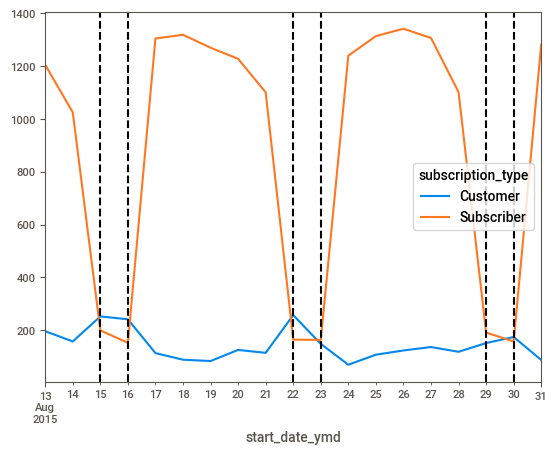

In [254]:
# subscription_typeごとのtrip_id数を時系列でプロット（ミクロ、休日ハイライト）
df_ = df_prep_trip[df_prep_trip["start_date"]>"2015-08-13"]
df_["start_date_ymd"] = df_["start_date"].dt.to_period("D")
df_ = df_.groupby(["start_date_ymd", "subscription_type"]).size().unstack().fillna(0)

plt.figure(figsize=(20, 8))
df_.plot()
# 休日を点線ハイライト
df_["weekend"] = df_.index.weekday
for row in df_[df_["weekend"]>=5].iterrows():
    plt.axvline(row[0], color="black", linestyle="--")

/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_26085/4277992869.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_["start_hour"] = df_["start_date"].dt.hour


<Axes: xlabel='start_hour'>

<Figure size 1500x800 with 0 Axes>

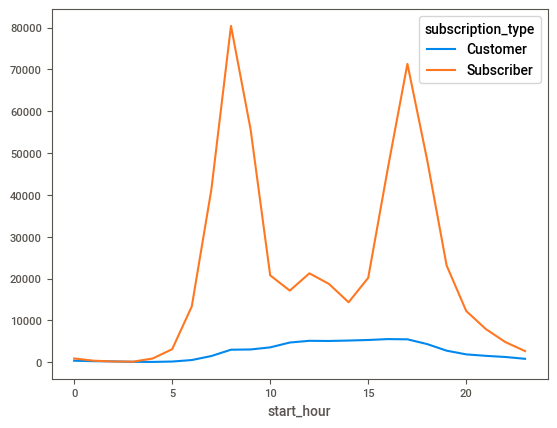

In [293]:
# 時間ごとのsubscription_typeごとのtrip_id数をプロット（平日）
plt.figure(figsize=(15, 8))
df_ = df_prep_trip
df_ = df_[df_["start_date"].dt.weekday<5]
df_["start_hour"] = df_["start_date"].dt.hour
df_ = df_.groupby(["start_hour", "subscription_type"]).size().unstack().fillna(0)
df_.plot()

/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_26085/2788433031.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_["start_hour"] = df_["start_date"].dt.hour


<Axes: xlabel='start_hour'>

<Figure size 1500x800 with 0 Axes>

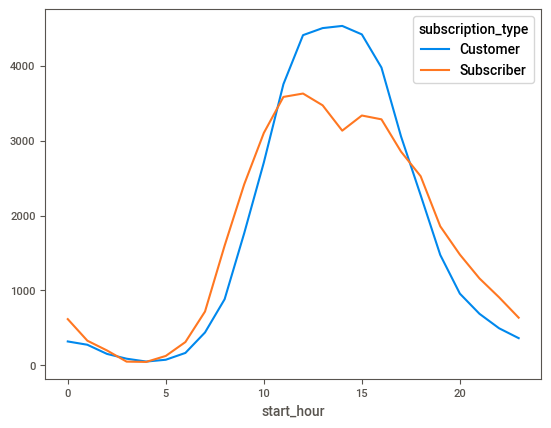

In [294]:
# 時間ごとのsubscription_typeごとのtrip_id数をプロット（休日）
plt.figure(figsize=(15, 8))
df_ = df_prep_trip
df_ = df_[df_["start_date"].dt.weekday>=5]
df_["start_hour"] = df_["start_date"].dt.hour
df_ = df_.groupby(["start_hour", "subscription_type"]).size().unstack().fillna(0)
df_.plot()

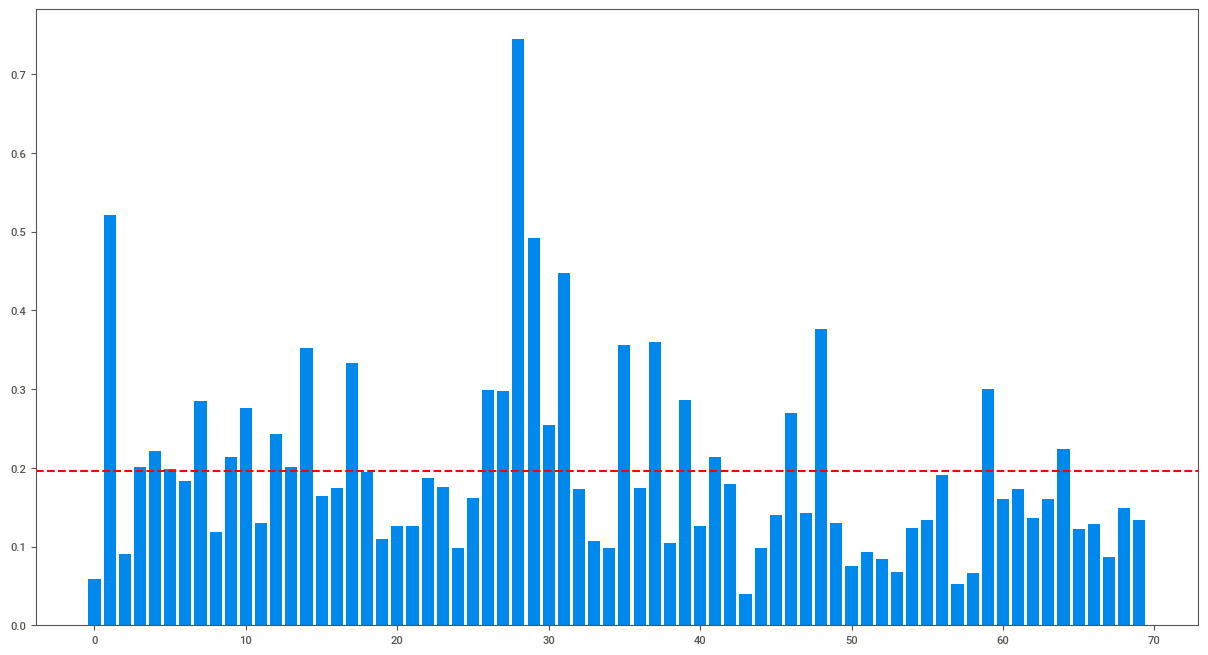

In [368]:
# station_idごとのCustomerの割合をプロット
df_ = df_prep_trip
df_ = df_.groupby(["start_station_id", "subscription_type"]).size().unstack().fillna(0)
df_["c_ratio"] = df_["Customer"]/(df_["Customer"]+df_["Subscriber"])
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111)
ax.bar(df_.index, df_["c_ratio"])
ax.axhline(df_["c_ratio"].mean(), color="red", linestyle="--")

In [369]:
# c_station_ids = df_[df_["c_ratio"]>df_["c_ratio"].mean()].index
c_station_ids = df_[df_["c_ratio"]>0.3].index

/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_26085/1190532097.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_c["start_date_ymd"] = df_c["start_date"].dt.to_period("D")
/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_26085/1190532097.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_s["start_date_ymd"] = df_s["start_date"].dt.to_period("D")


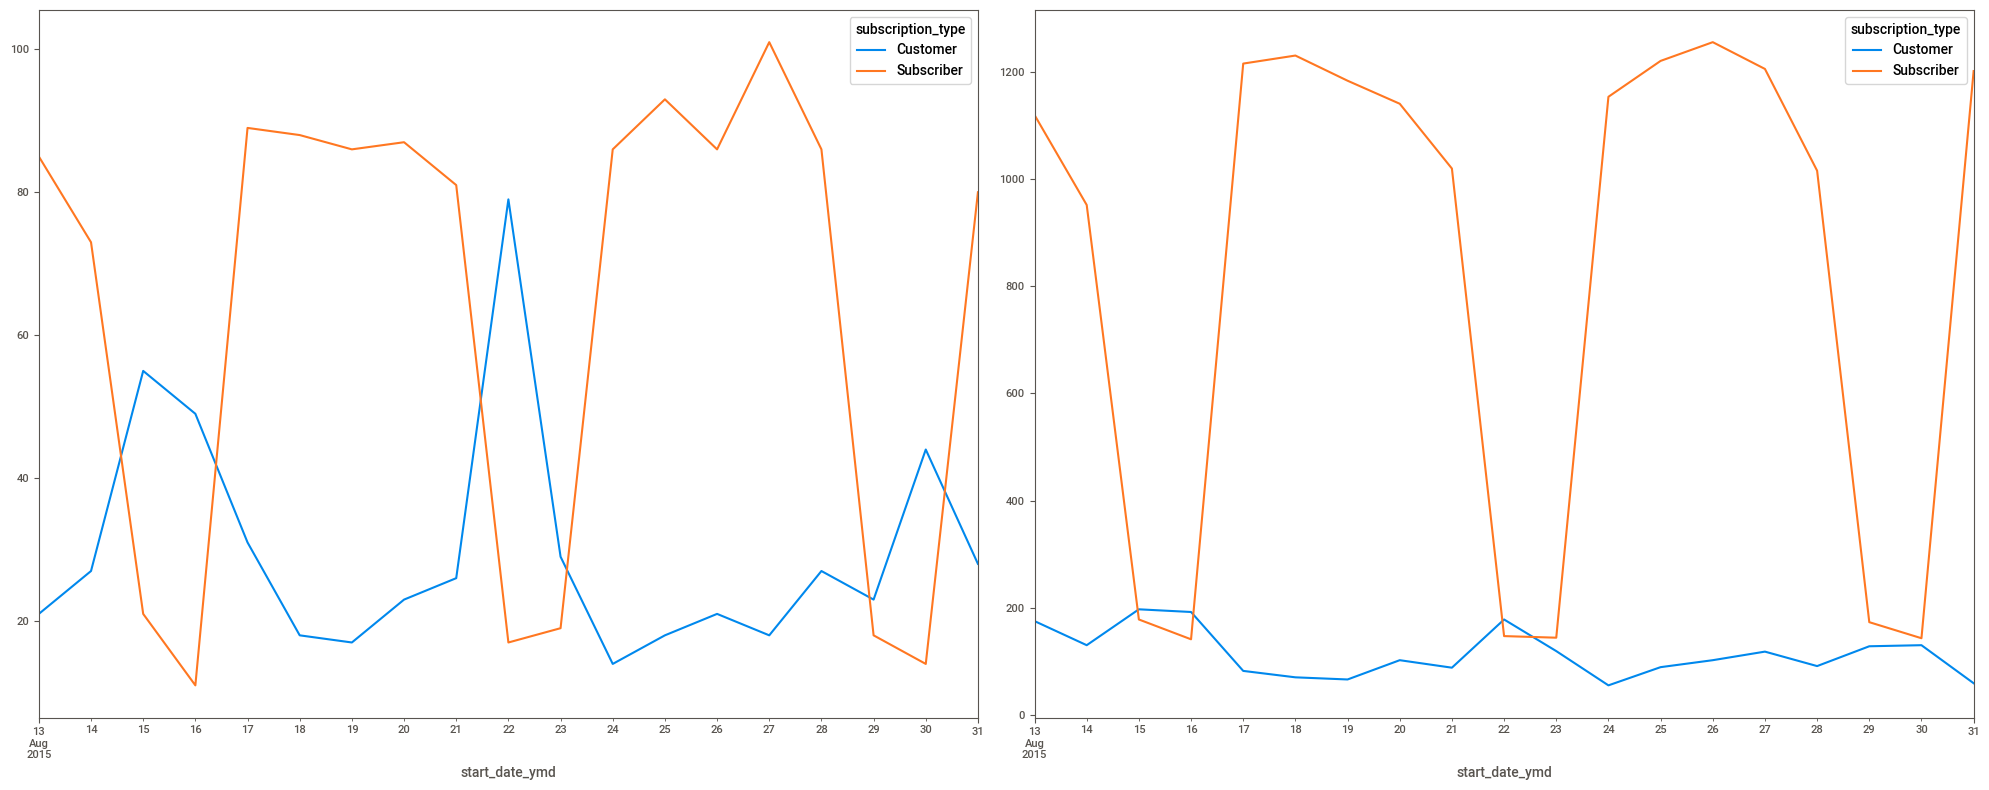

In [355]:
# subscription_typeごとのtrip_id数を時系列でプロット（ミクロ、休日ハイライト）
df_c = df_prep_trip[(df_prep_trip["start_date"]>"2015-08-13") & (df_prep_trip["start_station_id"].isin(c_station_ids))]
df_s = df_prep_trip[(df_prep_trip["start_date"]>"2015-08-13") & (~df_prep_trip["start_station_id"].isin(c_station_ids))]
df_c["start_date_ymd"] = df_c["start_date"].dt.to_period("D")
df_s["start_date_ymd"] = df_s["start_date"].dt.to_period("D")
df_c = df_c.groupby(["start_date_ymd", "subscription_type"]).size().unstack().fillna(0)
df_s = df_s.groupby(["start_date_ymd", "subscription_type"]).size().unstack().fillna(0)

fig = plt.figure(figsize=(20, 8))
df_c.plot(ax=fig.add_subplot(1,2,1))
df_s.plot(ax=fig.add_subplot(1,2,2))
fig.tight_layout()

<Axes: xlabel='start_hour'>

<Figure size 1500x800 with 0 Axes>

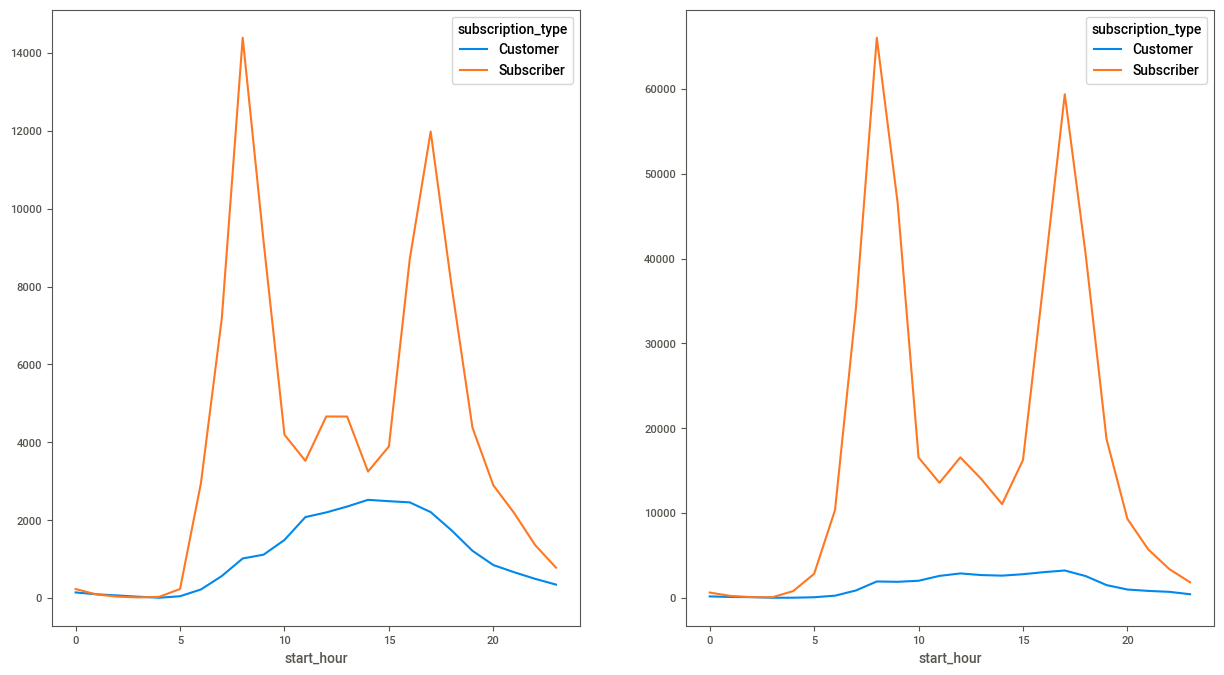

In [314]:
# 時間ごとのsubscription_typeごとのtrip_id数をプロット（平日）
plt.figure(figsize=(15, 8))
df_c = df_prep_trip[df_prep_trip["start_station_id"].isin(c_station_ids)]
df_s = df_prep_trip[~df_prep_trip["start_station_id"].isin(c_station_ids)]
df_c = df_c[df_c["start_date"].dt.weekday<5]
df_s = df_s[df_s["start_date"].dt.weekday<5]
df_c["start_hour"] = df_c["start_date"].dt.hour
df_s["start_hour"] = df_s["start_date"].dt.hour
df_c = df_c.groupby(["start_hour", "subscription_type"]).size().unstack().fillna(0)
df_s = df_s.groupby(["start_hour", "subscription_type"]).size().unstack().fillna(0)
fig = plt.figure(figsize=(15, 8))
df_c.plot(ax=fig.add_subplot(1,2,1))
df_s.plot(ax=fig.add_subplot(1,2,2))

<Axes: xlabel='start_hour'>

<Figure size 3000x800 with 0 Axes>

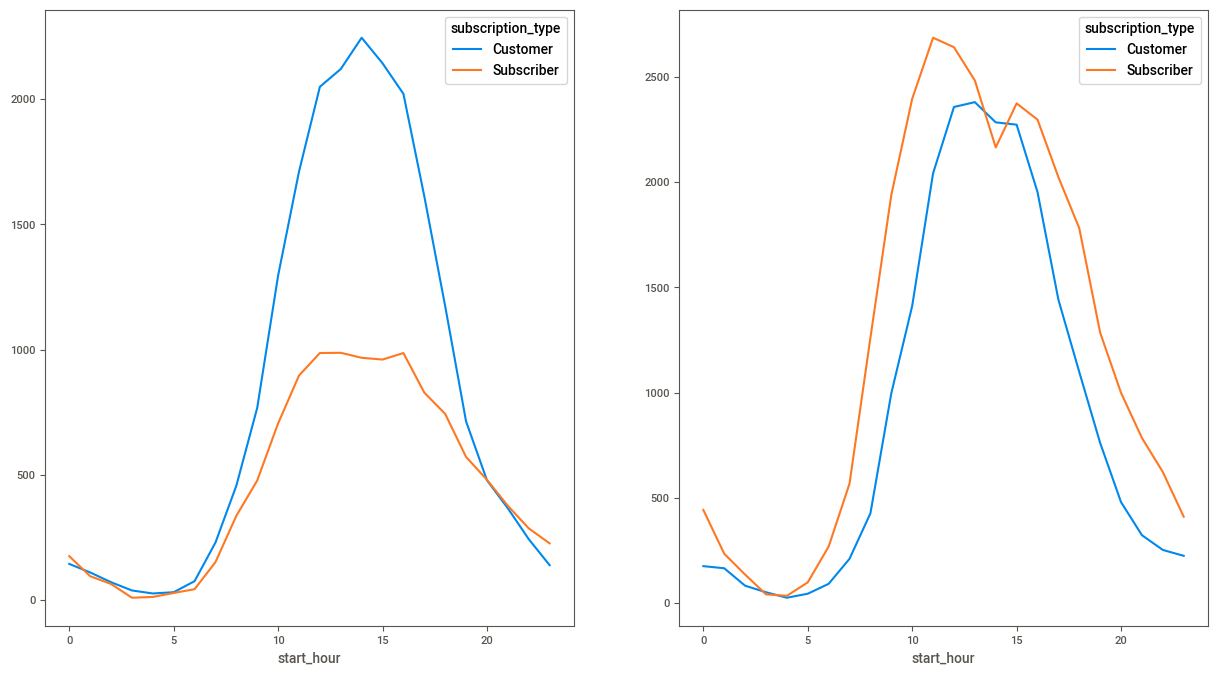

In [313]:
# 時間ごとのsubscription_typeごとのtrip_id数をプロット（平日）
plt.figure(figsize=(30, 8))
df_c = df_prep_trip[df_prep_trip["start_station_id"].isin(c_station_ids)]
df_s = df_prep_trip[~df_prep_trip["start_station_id"].isin(c_station_ids)]
df_c = df_c[df_c["start_date"].dt.weekday>=5]
df_s = df_s[df_s["start_date"].dt.weekday>=5]
df_c["start_hour"] = df_c["start_date"].dt.hour
df_s["start_hour"] = df_s["start_date"].dt.hour
df_c = df_c.groupby(["start_hour", "subscription_type"]).size().unstack().fillna(0)
df_s = df_s.groupby(["start_hour", "subscription_type"]).size().unstack().fillna(0)
fig = plt.figure(figsize=(15, 8))
df_c.plot(ax=fig.add_subplot(1,2,1))
df_s.plot(ax=fig.add_subplot(1,2,2))

<Axes: xlabel='datetime'>

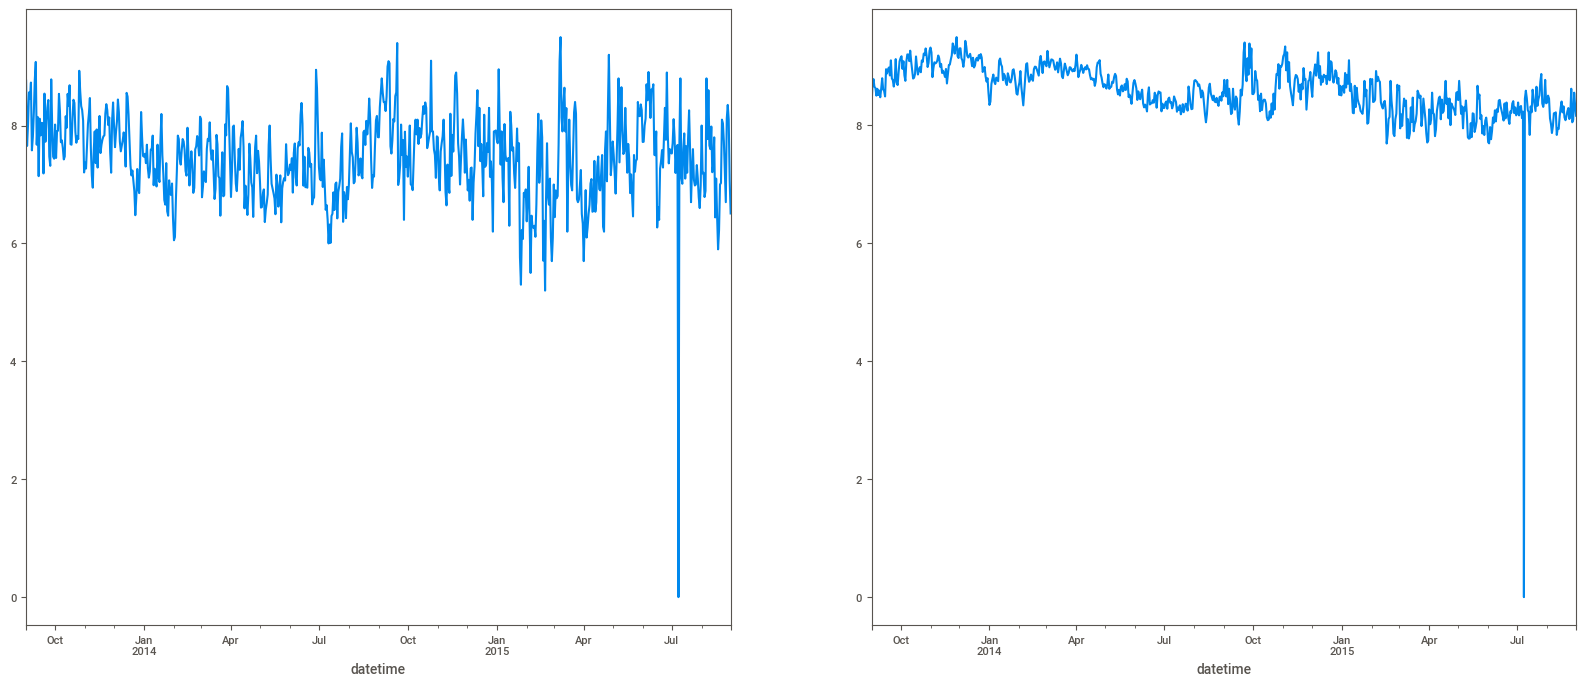

In [370]:
# subscription_type比率ごとのstation_idのbike_availablesを時系列でプロット
df_ = df_prep_status_station.copy()
df_["datetime"] = df_["datetime"].dt.to_period("D")
df_c = df_[df_["station_id"].isin(c_station_ids)]
df_s = df_[~df_["station_id"].isin(c_station_ids)]
df_c = df_c.groupby("datetime")["bikes_available"].mean().fillna(0)
df_s = df_s.groupby("datetime")["bikes_available"].mean().fillna(0)
fig = plt.figure(figsize=(20, 8))
df_c.plot(ax=fig.add_subplot(1,2,1))
df_s.plot(ax=fig.add_subplot(1,2,2))

<Axes: xlabel='subscription_type', ylabel='duration'>

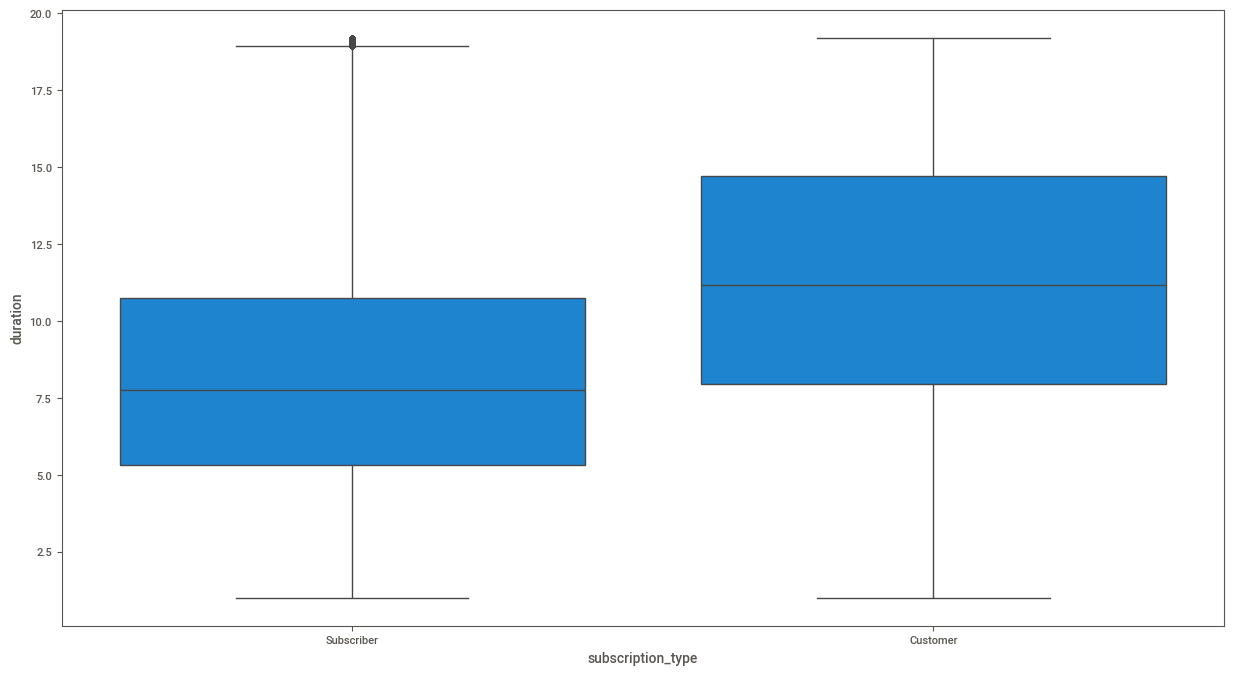

In [387]:
# subscription_typeごとのdurationの箱ヒゲ図をプロット
# 90%タイルを除外
df_ = df_prep_trip.copy()
df_["duration"] = df_["duration"] / 60
df_ = df_[df_["duration"]<df_["duration"].quantile(0.9)]
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_, x="subscription_type", y="duration")

# weather

In [403]:
df_prep_weather.head()

,date,max_temperature,mean_temperature,min_temperature,max_dew_point,mean_dew_point,min_dew_point,max_humidity,mean_humidity,min_humidity,max_sea_level_pressure,mean_sea_level_pressure,min_sea_level_pressure,max_visibility,mean_visibility,min_visibility,max_wind_Speed,mean_wind_speed,precipitation,cloud_cover,events,wind_dir_degrees
0,2013-09-01,81,70,61,62,58,54,80,67,47,29.94,29.95,29.85,10,10,10,14,4,0.00,1,NaN,354
1,2013-09-02,80,71,66,64,61,58,80,70,58,29.95,29.95,29.86,10,10,10,14,4,0.00,5,NaN,337
2,2013-09-03,81,69,58,60,56,52,82,65,44,29.99,29.99,29.93,10,10,10,19,2,1.71,6,Rain,341
3,2013-09-04,82,68,56,61,55,49,81,64,43,30.04,30.02,29.94,10,10,10,15,0,0.00,0,NaN,324
4,2013-09-05,81,68,56,59,54,50,81,63,41,30.02,30.02,29.95,10,10,10,16,1,0.00,0,NaN,335


In [ ]:
df_sta
df_status_weather = pd.merge(df_prep_status, df_prep_weather, on="datetime", how="left")

In [421]:
df_prep_status["date"] = df_prep_status["datetime"]

In [417]:
df_prep_status["date"][0] == df_prep_weather["date"][0]

False

In [427]:
df_prep_status["datetime"].dt.to_period("D")[0]

0          2013-09-01
1          2013-09-01
2          2013-09-01
3          2013-09-01
4          2013-09-01
              ...    
1226395    2015-08-31
1226396    2015-08-31
1226397    2015-08-31
1226398    2015-08-31
1226399    2015-08-31
Name: datetime, Length: 1226400, dtype: period[D]

In [422]:
df_prep_weather["date"]

0     2013-09-01
1     2013-09-02
2     2013-09-03
3     2013-09-04
4     2013-09-05
         ...    
725   2015-08-27
726   2015-08-28
727   2015-08-29
728   2015-08-30
729   2015-08-31
Name: date, Length: 730, dtype: datetime64[ns]

In [428]:
df_prep_status["datetime"]. == df_prep_weather["date"][0]

False